In [2]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, state_fidelity
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import random
import time
print("All packages imported successfully.")

All packages imported successfully.


Random Quantum Circuit Generated
Seed             : 2581
Number of Qubits : 6
Circuit Depth    : 14
Total Gates      : 63


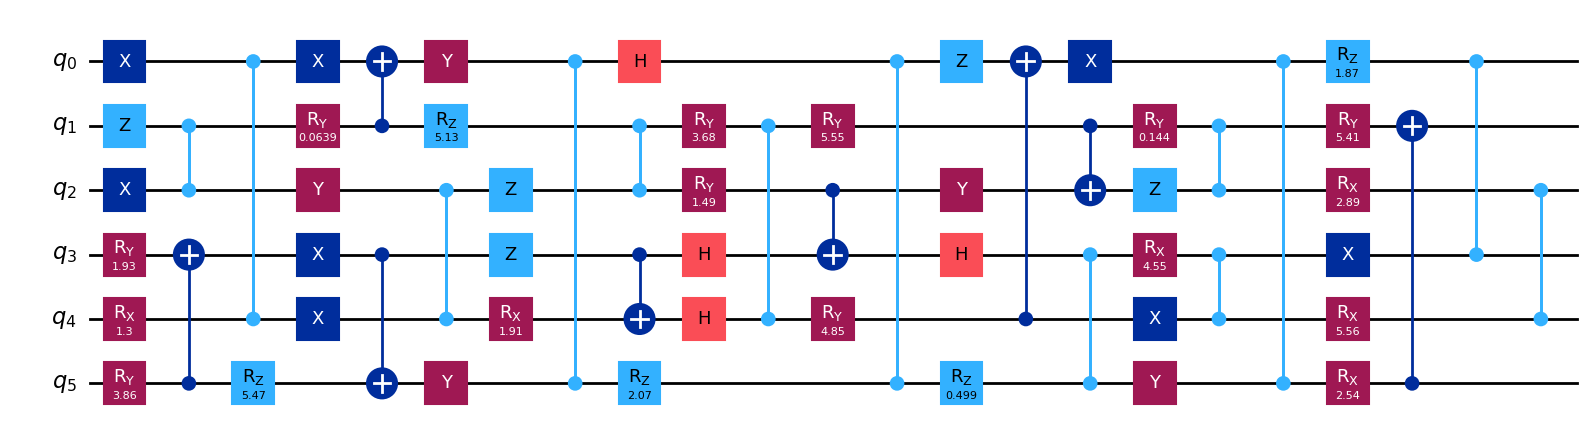

In [3]:


def generate_random_circuit():
    seed = random.randint(0, 99999)
    random.seed(seed)
    np.random.seed(seed)
    
    num_qubits = random.randint(4, 12)
    depth = random.randint(5, 10)
    qc = QuantumCircuit(num_qubits)
    
    single_gates = ['h', 'x', 'y', 'z', 'rx', 'ry', 'rz']
    two_gates = ['cx', 'cz']
    
    for _ in range(depth):
        for q in range(num_qubits):
            gate = random.choice(single_gates)
            if gate in ['rx', 'ry', 'rz']:
                theta = np.random.uniform(0, 2 * np.pi)
                getattr(qc, gate)(theta, q)
            else:
                getattr(qc, gate)(q)
        
        qubits = random.sample(range(num_qubits), num_qubits)
        for i in range(0, num_qubits - 1, 2):
            gate = random.choice(two_gates)
            if gate == 'cx':
                qc.cx(qubits[i], qubits[i + 1])
            else:
                qc.cz(qubits[i], qubits[i + 1])
    
    print("=" * 50)
    print("Random Quantum Circuit Generated")
    print(f"Seed             : {seed}")
    print(f"Number of Qubits : {num_qubits}")
    print(f"Circuit Depth    : {qc.depth()}")
    print(f"Total Gates      : {len(qc.data)}")
    print("=" * 50)
    
    return qc

qc = generate_random_circuit()

qc.draw("mpl", fold=40)

In [5]:
def circuit_to_graph(circuit):
    G = nx.Graph()
    for q in range(circuit.num_qubits):
        G.add_node(q, label=f"q{q}")
    for instruction in circuit.data:
        if len(instruction.qubits) == 2:
            q0 = circuit.qubits.index(instruction.qubits[0])
            q1 = circuit.qubits.index(instruction.qubits[1])
            gate_name = instruction.operation.name
            G.add_edge(q0, q1, gate=gate_name)
    return G

G = circuit_to_graph(qc)
print("Qubit Interaction Graph")
print(f"  Nodes (qubits) : {G.number_of_nodes()}")
print(f"  Edges (2q gates): {G.number_of_edges()}")
print("\nEdge list:")
for u, v, data in G.edges(data=True):
    print(f"  q{u} -- q{v}  [{data['gate'].upper()}]")

Qubit Interaction Graph
  Nodes (qubits) : 6
  Edges (2q gates): 11

Edge list:
  q0 -- q4  [CX]
  q0 -- q1  [CX]
  q0 -- q5  [CZ]
  q0 -- q3  [CZ]
  q1 -- q2  [CZ]
  q1 -- q4  [CZ]
  q1 -- q5  [CX]
  q2 -- q4  [CZ]
  q2 -- q3  [CX]
  q3 -- q5  [CZ]
  q3 -- q4  [CZ]


In [6]:
def count_cuts(G, partA, partB):
    return sum(
        1 for u, v in G.edges()
        if (u in partA and v in partB) or (u in partB and v in partA)
    )

def kernighan_lin_partition(G, num_qubits, seed=42):
    random.seed(seed)
    all_qubits = list(range(num_qubits))
    random.shuffle(all_qubits)
    half  = num_qubits // 2

    # Step 1: Random starting partition
    partA = set(all_qubits[:half])
    partB = set(all_qubits[half:])

    start_time   = time.time()
    current_cuts = count_cuts(G, partA, partB)
    improved     = True
    passes       = 0

    while improved:
        improved  = False
        passes   += 1
        best_gain = 0
        best_swap = None

        # Step 2: Try every pair (a from A, b from B)
        for a in list(partA):
            for b in list(partB):
                # Temporarily swap
                partA.remove(a); partA.add(b)
                partB.remove(b); partB.add(a)

                new_cuts = count_cuts(G, partA, partB)
                gain     = current_cuts - new_cuts

                # Undo swap
                partA.remove(b); partA.add(a)
                partB.remove(a); partB.add(b)

                if gain > best_gain:
                    best_gain = gain
                    best_swap = (a, b)

        # Step 3: Apply the best swap found
        if best_swap is not None:
            a, b = best_swap
            partA.remove(a); partA.add(b)
            partB.remove(b); partB.add(a)
            current_cuts -= best_gain
            improved      = True

    runtime   = time.time() - start_time
    cut_edges = [
        (u, v, data["gate"])
        for u, v, data in G.edges(data=True)
        if (u in partA) != (v in partA)
    ]
    return (partA, partB), cut_edges, current_cuts, runtime, passes


print("Running Kernighan-Lin Partitioning...")
(
    best_partition,
    best_cut_edges,
    minimum_cut_count,
    kl_runtime,
    passes
) = kernighan_lin_partition(G, qc.num_qubits)

partA, partB = best_partition

print("\n" + "=" * 50)
print("  KERNIGHAN-LIN PARTITION RESULTS")
print("=" * 50)
print(f"  Passes until convergence : {passes}")
print(f"  Runtime                  : {kl_runtime:.4f} seconds")
print(f"  Minimum Cut Count        : {minimum_cut_count}")
print()
print(f"  Group A (qubits) : {sorted(partA)}")
print(f"  Group B (qubits) : {sorted(partB)}")
print()
print("  Cut Gates (cross-partition):")
for u, v, gate in best_cut_edges:
    print(f"    {gate.upper():5s}  q{u}  <-->  q{v}")
print("=" * 50)

Running Kernighan-Lin Partitioning...

  KERNIGHAN-LIN PARTITION RESULTS
  Passes until convergence : 2
  Runtime                  : 0.0010 seconds
  Minimum Cut Count        : 5

  Group A (qubits) : [2, 3, 4]
  Group B (qubits) : [0, 1, 5]

  Cut Gates (cross-partition):
    CX     q0  <-->  q4
    CZ     q0  <-->  q3
    CZ     q1  <-->  q2
    CZ     q1  <-->  q4
    CZ     q3  <-->  q5


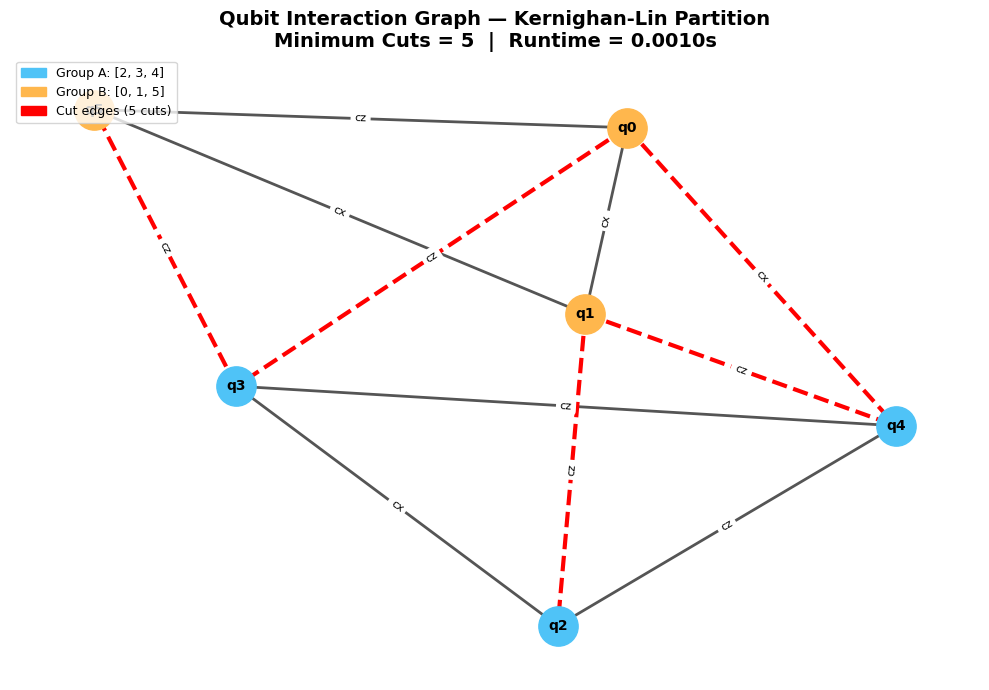

In [7]:
def draw_interaction_graph(G, partA, partB, cut_edges_list, title="Qubit Interaction Graph"):
    fig, ax = plt.subplots(figsize=(10, 7))
    pos = nx.spring_layout(G, seed=42, k=1.5)
    cut_edge_set   = {(u, v) for u, v, _ in cut_edges_list} | \
                     {(v, u) for u, v, _ in cut_edges_list}
    internal_edges = [(u, v) for u, v in G.edges() if (u, v) not in cut_edge_set]
    cut_edges_draw = [(u, v) for u, v in G.edges() if (u, v) in cut_edge_set]
    nx.draw_networkx_nodes(G, pos, nodelist=list(partA),
                           node_color="#4fc3f7", node_size=800, ax=ax)
    nx.draw_networkx_nodes(G, pos, nodelist=list(partB),
                           node_color="#ffb74d", node_size=800, ax=ax)
    nx.draw_networkx_edges(G, pos, edgelist=internal_edges,
                           width=2.0, edge_color="#555555", ax=ax)
    nx.draw_networkx_edges(G, pos, edgelist=cut_edges_draw,
                           width=3.0, edge_color="red", style="dashed", ax=ax)
    nx.draw_networkx_labels(G, pos,
                            labels={n: f"q{n}" for n in G.nodes()},
                            font_size=10, font_weight="bold", ax=ax)
    edge_labels = nx.get_edge_attributes(G, "gate")
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                                 font_size=8, ax=ax)
    legend_handles = [
        mpatches.Patch(color="#4fc3f7", label=f"Group A: {sorted(partA)}"),
        mpatches.Patch(color="#ffb74d", label=f"Group B: {sorted(partB)}"),
        mpatches.Patch(color="red",     label=f"Cut edges ({len(cut_edges_list)} cuts)"),
    ]
    ax.legend(handles=legend_handles, loc="upper left", fontsize=9)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

draw_interaction_graph(
    G, partA, partB, best_cut_edges,
    title=f"Qubit Interaction Graph — Kernighan-Lin Partition\n"
          f"Minimum Cuts = {minimum_cut_count}  |  Runtime = {kl_runtime:.4f}s"
)

Subcircuit A — qubits [2, 3, 4]
  Gates: 26, Depth: 12


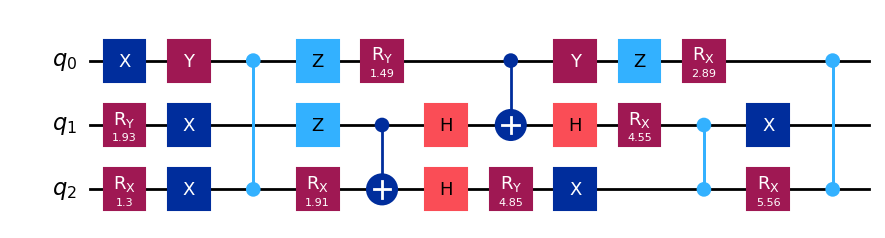

In [8]:
def extract_subcircuit(circuit, qubit_group, cut_edges):
    sorted_group = sorted(qubit_group)
    qubit_map    = {old: new for new, old in enumerate(sorted_group)}
    n_sub        = len(sorted_group)
    sub_qc       = QuantumCircuit(n_sub)
    cut_pairs    = {(u, v) for u, v, _ in cut_edges} | \
                   {(v, u) for u, v, _ in cut_edges}
    for instruction in circuit.data:
        qubit_indices = [
            circuit.qubits.index(q) for q in instruction.qubits
        ]
        if len(qubit_indices) == 1:
            q = qubit_indices[0]
            if q in qubit_group:
                sub_qc.append(instruction.operation, [qubit_map[q]])
        elif len(qubit_indices) == 2:
            q0, q1 = qubit_indices
            if q0 in qubit_group and q1 in qubit_group:
                if (q0, q1) not in cut_pairs:
                    sub_qc.append(
                        instruction.operation,
                        [qubit_map[q0], qubit_map[q1]]
                    )
    return sub_qc, sorted_group

sub_A, qubits_A = extract_subcircuit(qc, partA, best_cut_edges)
sub_B, qubits_B = extract_subcircuit(qc, partB, best_cut_edges)
print(f"Subcircuit A — qubits {qubits_A}")
print(f"  Gates: {len(sub_A.data)}, Depth: {sub_A.depth()}")
sub_A.draw("mpl")

Subcircuit B — qubits [0, 1, 5]
  Gates: 26, Depth: 12


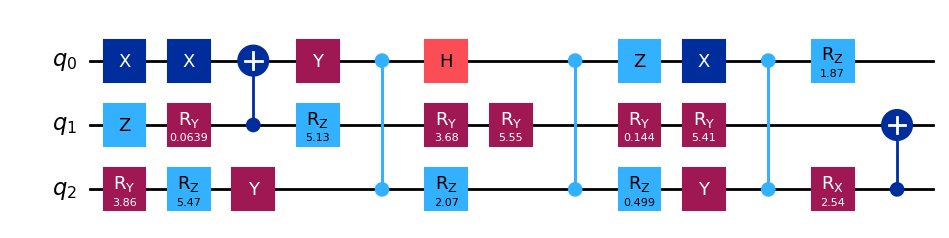

In [9]:
print(f"Subcircuit B — qubits {qubits_B}")
print(f"  Gates: {len(sub_B.data)}, Depth: {sub_B.depth()}")
sub_B.draw("mpl")

--- Reconstructed Circuit (cut gates removed) ---
Original depth     : 14
Reconstructed depth: 12
Gates removed      : 11 (the 5 cut gates)


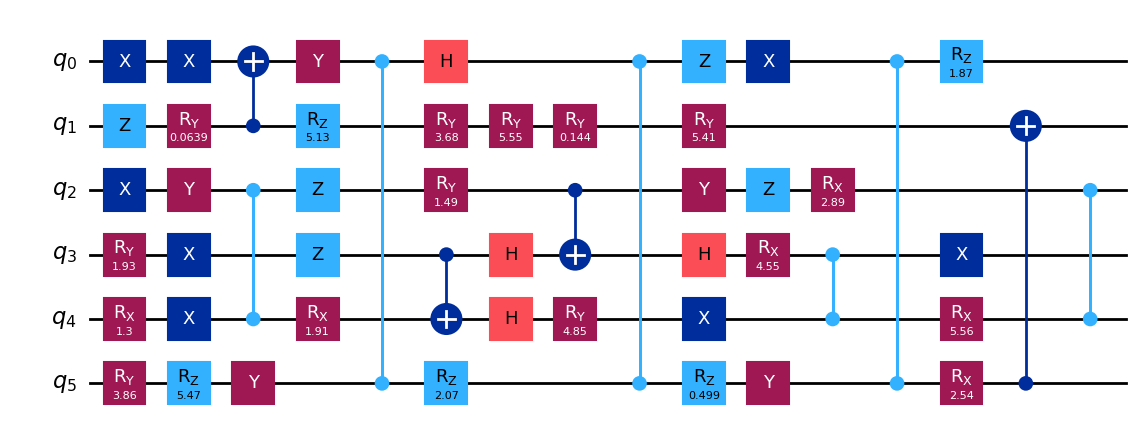

In [10]:
def reconstruct_circuit(circuit, cut_edges):
    cut_pairs     = {(u, v) for u, v, _ in cut_edges} | \
                    {(v, u) for u, v, _ in cut_edges}
    reconstructed = QuantumCircuit(circuit.num_qubits)
    for instruction in circuit.data:
        qubit_indices = [
            circuit.qubits.index(q) for q in instruction.qubits
        ]
        if len(qubit_indices) == 2:
            q0, q1 = qubit_indices
            if (q0, q1) in cut_pairs:
                continue
        reconstructed.append(instruction.operation, qubit_indices)
    return reconstructed

reconstructed_qc = reconstruct_circuit(qc, best_cut_edges)
print("--- Reconstructed Circuit (cut gates removed) ---")
print(f"Original depth     : {qc.depth()}")
print(f"Reconstructed depth: {reconstructed_qc.depth()}")
print(f"Gates removed      : {len(qc.data) - len(reconstructed_qc.data)} (the {minimum_cut_count} cut gates)")
reconstructed_qc.draw("mpl", fold=40)

In [11]:
print("Computing statevectors (this may take a moment for 12 qubits)...")
original_sv      = Statevector.from_instruction(qc)
reconstructed_sv = Statevector.from_instruction(reconstructed_qc)
kl_fidelity      = state_fidelity(original_sv, reconstructed_sv)
print()
print("=" * 50)
print("  FIDELITY RESULT")
print("=" * 50)
print(f"  Fidelity = {kl_fidelity:.6f}")
print()
if kl_fidelity > 0.99:
    print("  ✓ Very high fidelity — cuts had minimal impact.")
elif kl_fidelity > 0.90:
    print("  ~ Good fidelity — some entanglement lost at cuts.")
else:
    print("  ✗ Low fidelity — significant entanglement lost at cuts.")
print("=" * 50)
print()
print("Note: Fidelity < 1.0 reflects entanglement lost by cutting")
print("cross-partition gates. True reconstruction via Pauli channel")
print("decomposition would restore fidelity = 1.0 at the cost of")
print("additional classical post-processing overhead.")

Computing statevectors (this may take a moment for 12 qubits)...

  FIDELITY RESULT
  Fidelity = 0.003326

  ✗ Low fidelity — significant entanglement lost at cuts.

Note: Fidelity < 1.0 reflects entanglement lost by cutting
cross-partition gates. True reconstruction via Pauli channel
decomposition would restore fidelity = 1.0 at the cost of
additional classical post-processing overhead.


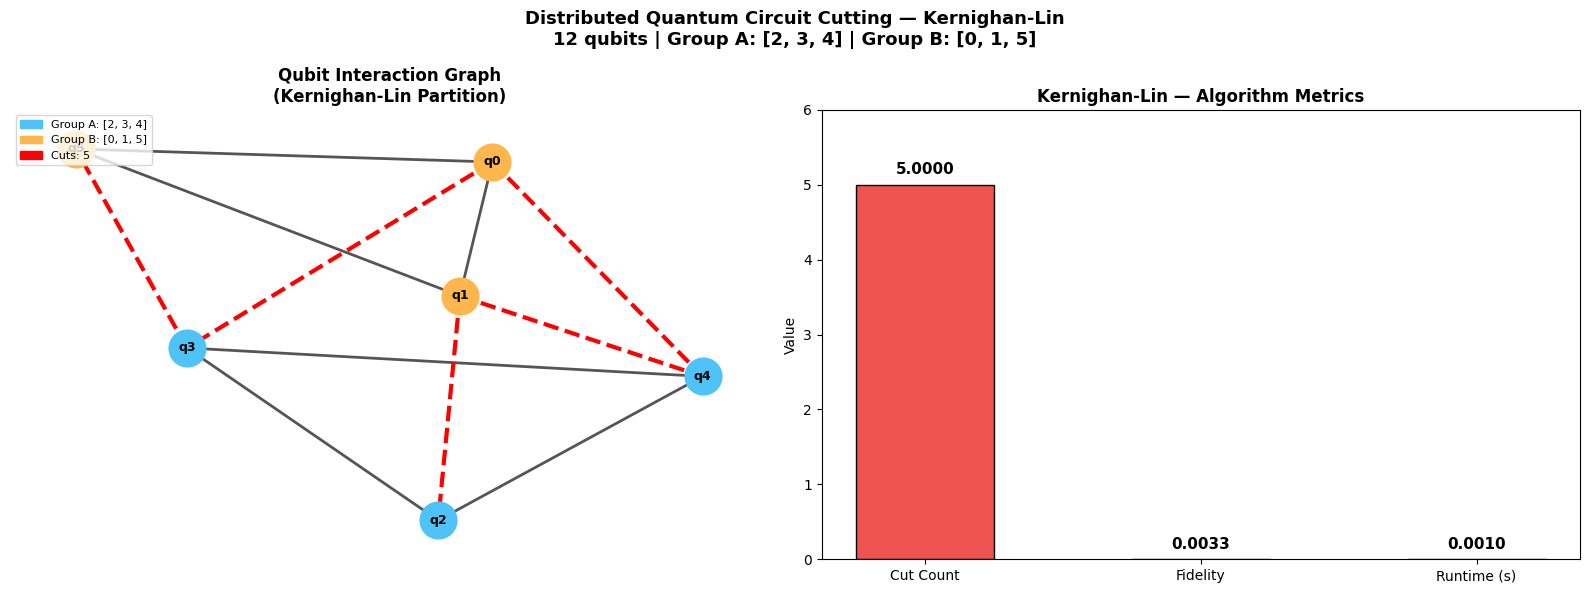

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: Qubit Interaction Graph ---
ax = axes[0]
pos = nx.spring_layout(G, seed=42, k=1.5)
cut_pair_set   = {(u, v) for u, v, _ in best_cut_edges} | \
                 {(v, u) for u, v, _ in best_cut_edges}
internal_edges = [(u, v) for u, v in G.edges() if (u, v) not in cut_pair_set]
cut_edges_draw = [(u, v) for u, v in G.edges() if (u, v) in cut_pair_set]
nx.draw_networkx_nodes(G, pos, nodelist=list(partA),
                       node_color="#4fc3f7", node_size=700, ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=list(partB),
                       node_color="#ffb74d", node_size=700, ax=ax)
nx.draw_networkx_edges(G, pos, edgelist=internal_edges,
                       width=2, edge_color="#555", ax=ax)
nx.draw_networkx_edges(G, pos, edgelist=cut_edges_draw,
                       width=3, edge_color="red", style="dashed", ax=ax)
nx.draw_networkx_labels(G, pos,
                        labels={n: f"q{n}" for n in G.nodes()},
                        font_size=9, font_weight="bold", ax=ax)
legend_handles = [
    mpatches.Patch(color="#4fc3f7", label=f"Group A: {sorted(partA)}"),
    mpatches.Patch(color="#ffb74d", label=f"Group B: {sorted(partB)}"),
    mpatches.Patch(color="red",     label=f"Cuts: {minimum_cut_count}"),
]
ax.legend(handles=legend_handles, loc="upper left", fontsize=8)
ax.set_title("Qubit Interaction Graph\n(Kernighan-Lin Partition)", fontweight="bold")
ax.axis("off")

# --- Right: Metrics Bar Chart ---
ax2 = axes[1]
metrics = ["Cut Count", "Fidelity", "Runtime (s)"]
values  = [minimum_cut_count, kl_fidelity, kl_runtime]
colors  = ["#ef5350", "#66bb6a", "#42a5f5"]
bars = ax2.bar(metrics, values, color=colors, width=0.5, edgecolor="black")
for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + max(values) * 0.02,
             f"{val:.4f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax2.set_title("Kernighan-Lin — Algorithm Metrics", fontweight="bold")
ax2.set_ylabel("Value")
ax2.set_ylim(0, max(values) * 1.2)
plt.suptitle(
    f"Distributed Quantum Circuit Cutting — Kernighan-Lin\n"
    f"12 qubits | Group A: {sorted(partA)} | Group B: {sorted(partB)}",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()